In [1]:
# 1. Importing necessary libraries for analysis and modeling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# 2. Loading the dataset
df = pd.read_csv('insurance.csv')

# Display first 5 rows
print("First 5 rows of dataset:")
display(df.head())

# Dataset Summary
print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows of dataset:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


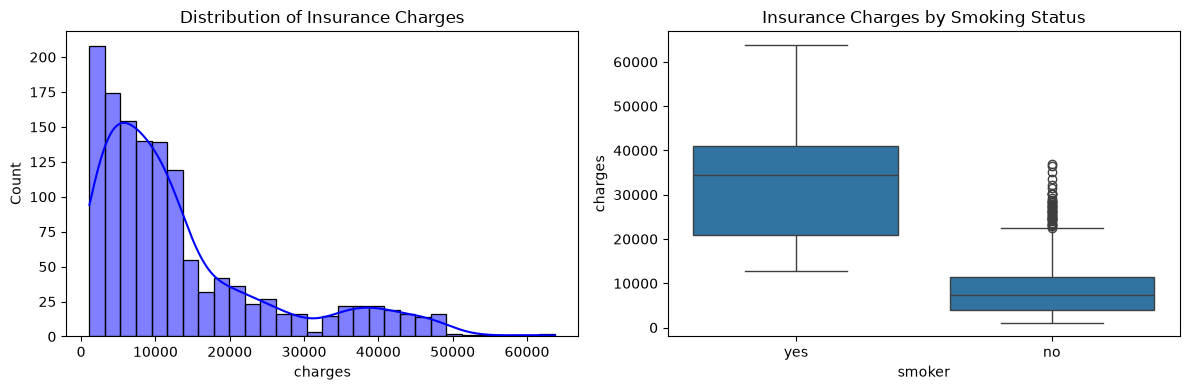

In [3]:
# 3. Visualizing relationships and distributions
plt.figure(figsize=(12, 4))

# Distribution of Charges
plt.subplot(1, 2, 1)
sns.histplot(df['charges'], kde=True, color='blue')
plt.title('Distribution of Insurance Charges')

# Smoker vs Charges
plt.subplot(1, 2, 2)
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Insurance Charges by Smoking Status')

plt.tight_layout()
plt.show()

In [4]:
# 4. Preprocessing categorical features
df_encoded = df.copy()

# Encoding binary columns
df_encoded['sex'] = df_encoded['sex'].map({'female': 0, 'male': 1})
df_encoded['smoker'] = df_encoded['smoker'].map({'no': 0, 'yes': 1})

# One-Hot Encoding for Region
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)

print("Preprocessed Data:")
display(df_encoded.head())

Preprocessed Data:


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [5]:
# 5. Splitting features (X) and target (y)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 1070 samples
Testing set size: 268 samples


In [6]:
# 6. Training multiple regression models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({
        "Model": name,
        "R2 Score": round(r2, 4),
        "MAE ($)": round(mae, 2),
        "RMSE ($)": round(rmse, 2)
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)
print("\n--- Model Comparison Summary ---")
display(results_df)


--- Model Comparison Summary ---


,Model,R2 Score,MAE ($),RMSE ($)
0,Linear Regression,0.7836,4181.19,5796.28
1,Decision Tree Regressor,0.6968,3384.47,6861.24
2,Random Forest Regressor,0.8651,2545.95,4575.51


In [7]:
# 7. Saving the best performing model (Random Forest)
best_model = models["Random Forest Regressor"]

# Save model and columns to disk
joblib.dump(best_model, 'best_insurance_model.pkl')
joblib.dump(X.columns.tolist(), 'model_columns.pkl')

print("Best Model ('best_insurance_model.pkl') and Features ('model_columns.pkl') saved successfully!")

Best Model ('best_insurance_model.pkl') and Features ('model_columns.pkl') saved successfully!
